# `local_authority_district` gap — and its fix

Discovered by the agent itself during the Task 9 evaluation run (Q4/Q5: "Which local
authority had the highest number of fatal collisions last year? And what about the
year before that?") — see `testing.ipynb` for the full reconstructed transcript. The
agent's first query returned nulls, so it ran several diagnostic queries on its own
initiative and worked out why.

**Update (2026-08-10):** `local_authority_district` itself is still sparse (unchanged,
see below) — the agent now has that column hidden from `get_schema` so it goes
straight to the alternatives. Those alternatives, `local_authority_highway` and
`local_authority_ons_district`, have since been fixed at the source: `full_ingestion.ipynb`
originally only decoded integer-coded fields, missing these two because they use
alphanumeric ONS codes (e.g. `E06000002`). They're now decoded to readable names the
same way every other coded field is.

This notebook demonstrates both facts directly against `data/road_safety.db`,
independent of the agent.

In [1]:
import sqlite3

import pandas as pd

DB_PATH = "data/road_safety.db"

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
coverage = pd.read_sql_query(
    """
    SELECT
        collision_year,
        COUNT(*) AS total_collisions,
        SUM(local_authority_district IS NOT NULL) AS district_populated,
        SUM(local_authority_highway IS NOT NULL) AS highway_populated,
        SUM(local_authority_ons_district IS NOT NULL) AS ons_populated
    FROM collision
    GROUP BY collision_year
    ORDER BY collision_year
    """,
    conn,
)
conn.close()
coverage

,collision_year,total_collisions,district_populated,highway_populated,ons_populated
0,2021,101087,194,99340,100893
1,2022,106004,0,104388,105828
2,2023,104258,0,101475,104258
3,2024,100927,0,98226,100927
4,2025,101525,0,97527,100323


**Reading this table:** `local_authority_district` is populated for only 194 of
101,087 collisions in 2021, and 0 in every other year — unchanged by the ingestion
fix, since it isn't a coded field the fix touches. `local_authority_highway` and
`local_authority_ons_district` are populated for ~97-100% of rows every year, and (as
of the ingestion fix above) now contain **readable names directly**, e.g.
"Stockton-on-Tees", not codes.

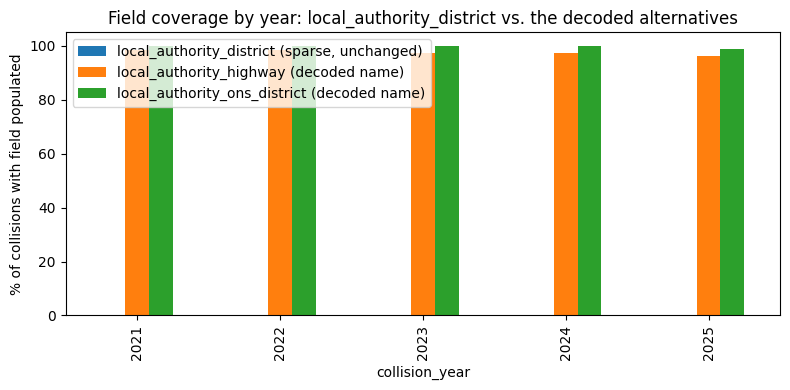

In [2]:
import matplotlib.pyplot as plt

coverage_pct = coverage.set_index("collision_year")[
    ["district_populated", "highway_populated", "ons_populated"]
].div(coverage.set_index("collision_year")["total_collisions"], axis=0) * 100

ax = coverage_pct.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("% of collisions with field populated")
ax.set_xlabel("collision_year")
ax.set_title("Field coverage by year: local_authority_district vs. the decoded alternatives")
ax.legend(["local_authority_district (sparse, unchanged)", "local_authority_highway (decoded name)", "local_authority_ons_district (decoded name)"])
plt.tight_layout()
plt.show()

## A new nuance from re-testing after the fix

Re-running the agent's Q4/Q5 questions against the fixed DB, it answered correctly
with a real name both times — but used a *different* field each run
(`local_authority_highway` once, `local_authority_ons_district` another time) and got
genuinely different top answers, because they're not duplicates: `local_authority_highway`
is the road-maintaining highway authority, `local_authority_ons_district` is the ONS
administrative district — legitimately different geographies for the same collision.
Demonstrated directly below.

In [3]:
conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
for field in ["local_authority_highway", "local_authority_ons_district"]:
    for year in (2024, 2025):
        top = pd.read_sql_query(
            f"""
            SELECT {field}, COUNT(*) AS fatal_collisions
            FROM collision
            WHERE collision_year = {year} AND collision_severity = 'Fatal'
            GROUP BY {field}
            ORDER BY fatal_collisions DESC
            LIMIT 3
            """,
            conn,
        )
        print(f"{field}, {year}:")
        print(top.to_string(index=False))
        print()
conn.close()

local_authority_highway, 2024:
local_authority_highway  fatal_collisions
                   None                64
           Lincolnshire                47
                   Kent                42

local_authority_highway, 2025:
local_authority_highway  fatal_collisions
                   None                99
                  Essex                43
                   Kent                38

local_authority_ons_district, 2024:
local_authority_ons_district  fatal_collisions
             North Yorkshire                23
                  Birmingham                23
                    Somerset                21

local_authority_ons_district, 2025:
local_authority_ons_district  fatal_collisions
             North Yorkshire                40
                  Birmingham                23
                   Wiltshire                20



Two further things worth knowing, visible in the output above — **all three now fixed
via system prompt v2/v3**, see the Takeaway below:

- **2024 has a genuine tie** on `local_authority_ons_district` (North Yorkshire and
  Birmingham both on 23 fatal collisions). v1's prompt let the agent's
  `ORDER BY ... LIMIT 1` silently pick one without mentioning the tie.
- **The two fields aren't interchangeable** (highway authority vs. ONS district), and
  v1's prompt gave the agent no reason not to pick one silently.
- **`local_authority_highway` has ~12,845 NULL rows**, and NULL is literally the top
  group above for both 2024 (64) and 2025 (99) — a naive query without an
  `IS NOT NULL` filter would report "unrecorded" as the answer.

## Takeaway

`local_authority_district`'s sparsity is a gap in `full_ingestion.ipynb`'s decoding
step, not an agent defect — and it's now handled three ways:

1. **Fixed at the source (done):** `local_authority_highway`/`local_authority_ons_district`
   are now decoded to readable names, the same way every other coded field is. This
   was the "option 1" originally proposed here.
2. **Worked around in the agent (done):** `local_authority_district` itself remains
   sparse and unfixed (it isn't a coded field, so the ingestion fix above doesn't touch
   it) — `get_schema` now hides it via `tools.EXCLUDED_COLUMNS` so the agent goes
   straight to the populated alternatives instead of rediscovering the gap turn by turn.
3. **Fixed via system prompt v2/v3 (done):** the agent now asks which of
   `local_authority_highway`/`local_authority_ons_district` is meant rather than
   picking one silently (v2), checks for ties on "highest/most/top" questions
   (`LIMIT 5` instead of `LIMIT 1`) rather than assuming a unique winner (v2), and
   excludes NULL rows from that kind of ranking so a large "unrecorded" group is never
   reported as the top answer (v3) — while leaving NULLs untouched in every other kind
   of query, since they're real rows, not deleted data. Confirmed live, including
   generalising to a column never mentioned in any worked example
   (`driver_imd_decile`) — see `testing.ipynb`'s "v3 re-run" section for the full
   transcripts.

No remaining open items from this investigation.